In [1]:
%cd ../

from wag_toolkit.locations import Locations
import pandas as pd
import json
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()

/Users/delapazm/Desktop/wellcome_academic_graph_toolkit/venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/Users/delapazm/Desktop/wellcome_academic_graph_toolkit


True

In [2]:
dummy_query = """MATCH (r:Researcher)-[a:AUTHORED]->(p:Publication) RETURN * LIMIT 1"""
query = """MATCH (r:Researcher)-[a:AUTHORED]->(p:Publication)
            WHERE p.dimensions_publication_id IN {}
            RETURN p.dimensions_publication_id AS dimensions_publication_id, p.year AS year,
                a.institutions AS grid_id"""

### Wellcome

In [3]:
wt_ch = pd.read_excel('geographies/CH_files/C&HPublicationExtraction.xlsx', sheet_name='Combined Awards')
grants_ref = pd.read_excel('geographies/CH_files/Manual Tagging of Grants with C&H goals.xlsx', sheet_name='Total C&H Awards_SM tagging')
grants_ref = grants_ref[grants_ref['C&H/C&H in partnership/wider portfolio (new)'].isin(['C&H', 'C&H in partnership'])]
grants_list = list(set(grants_ref['Grant Reference'].to_list()))
wt_ch = wt_ch[wt_ch['Wellcome Grant Reference'].isin(grants_list)]

wt_pub_ids = list(set(wt_ch['Publication ID'].tolist()))

wt_ch_loc = Locations(dummy_query)
wt_ch_loc.lookup_query(query=query, lookup=wt_pub_ids)

data =pd.DataFrame(wt_ch_loc.data)
data = data.explode("grid_id").dropna()

wt_ch_loc._clean_grid_ids()
wt_ch_loc.extract_edges()
wt_ch_loc.extract_locations("country")

wt_ch_loc.convert_edges()
wt_ch_loc.calculate_adjacency_matrices()

import numpy as np
wt_ch_loc.adjacency_matrices = {np.int64(key): value for key, value in wt_ch_loc.adjacency_matrices.items()}


100%|██████████| 1/1 [00:00<00:00,  7.36it/s]
/Users/delapazm/Desktop/wellcome_academic_graph_toolkit/wag_toolkit/locations.py:183: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df = pd.crosstab(
/Users/delapazm/Desktop/wellcome_academic_graph_toolkit/wag_toolkit/locations.py:183: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df = pd.crosstab(
/Users/delapazm/Desktop/wellcome_academic_graph_toolkit/wag_toolkit/locations.py:183: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep cu

2022.0
2021.0
2023.0
2017.0
2015.0
2019.0
2018.0
2016.0
2020.0


/Users/delapazm/Desktop/wellcome_academic_graph_toolkit/wag_toolkit/locations.py:183: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df = pd.crosstab(
/Users/delapazm/Desktop/wellcome_academic_graph_toolkit/wag_toolkit/locations.py:183: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df = pd.crosstab(
/Users/delapazm/Desktop/wellcome_academic_graph_toolkit/wag_toolkit/locations.py:183: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.


### All CH

In [4]:
all_ch = pd.read_parquet('geographies/CH_files/climate_health_intersection_just_ids.parquet')
all_pub_ids = list(set(all_ch['publication_id'].tolist()))

pub_ids = list(set(all_pub_ids)-set(wt_pub_ids))
print(len(set(all_pub_ids)), len(set(wt_pub_ids)))

all_ch_loc = Locations(dummy_query)
all_ch_loc.lookup_query(query=query, lookup=pub_ids)

data =pd.DataFrame(all_ch_loc.data)
data = data.explode("grid_id").dropna()

all_ch_loc._clean_grid_ids()
all_ch_loc.extract_edges()
all_ch_loc.extract_locations("country")

all_ch_loc.convert_edges()
all_ch_loc.calculate_adjacency_matrices()

95422 1011


100%|██████████| 14/14 [00:02<00:00,  5.87it/s]


2023
2022
2019
2021
2014
2020


/Users/delapazm/Desktop/wellcome_academic_graph_toolkit/wag_toolkit/locations.py:183: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df = pd.crosstab(
/Users/delapazm/Desktop/wellcome_academic_graph_toolkit/wag_toolkit/locations.py:183: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df = pd.crosstab(
/Users/delapazm/Desktop/wellcome_academic_graph_toolkit/wag_toolkit/locations.py:183: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.


2015
2016
2017
2018


/Users/delapazm/Desktop/wellcome_academic_graph_toolkit/wag_toolkit/locations.py:183: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df = pd.crosstab(
/Users/delapazm/Desktop/wellcome_academic_graph_toolkit/wag_toolkit/locations.py:183: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df = pd.crosstab(
/Users/delapazm/Desktop/wellcome_academic_graph_toolkit/wag_toolkit/locations.py:183: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.


## Visualisations

### International Coauthors

In [12]:
all_ch_int = {}

for year in all_ch_loc.adjacency_matrices:
    inter = 0
    for country in all_ch_loc.adjacency_matrices[year]['All'].index:
        if country == 'All' or country == 'total':
            continue
        inter += (all_ch_loc.adjacency_matrices[year]['All'][country]['All']-all_ch_loc.adjacency_matrices[year]['All'][country][country])
    all_ch_int[year] = (inter, all_ch_loc.adjacency_matrices[year]['All']['All']['All'])

In [13]:
wt_ch_int = {}

for year in wt_ch_loc.adjacency_matrices:
    inter = 0
    for country in wt_ch_loc.adjacency_matrices[year]['All'].index:
        if country == 'All' or country == 'total':
            continue
        inter += (wt_ch_loc.adjacency_matrices[year]['All'][country]['All']-wt_ch_loc.adjacency_matrices[year]['All'][country][country])
    wt_ch_int[year] = (inter, wt_ch_loc.adjacency_matrices[year]['All']['All']['All'])

In [14]:
all_ch_loc.adjacency_matrices.keys()

dict_keys([np.int64(2023), np.int64(2022), np.int64(2019), np.int64(2021), np.int64(2014), np.int64(2020), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)])

In [15]:
wt_ch_loc.adjacency_matrices.keys()

dict_keys([np.int64(2022), np.int64(2021), np.int64(2023), np.int64(2017), np.int64(2015), np.int64(2019), np.int64(2018), np.int64(2016), np.int64(2020)])

In [16]:
pct_ch = {}
pct_wt = {}

sorted_years = sorted(all_ch_loc.adjacency_matrices.keys())
sorted_years = sorted_years[1:-1]

for year in all_ch_loc.adjacency_matrices:
    pct_ch[year] = all_ch_int[year][0]*100/all_ch_int[year][1]

pct_ch_values = [pct_ch[year] for year in sorted_years]

for year in wt_ch_loc.adjacency_matrices:
    pct_wt[year] =wt_ch_int[year][0]*100/wt_ch_int[year][1]

pct_wt_values = [pct_wt[year] for year in sorted_years]

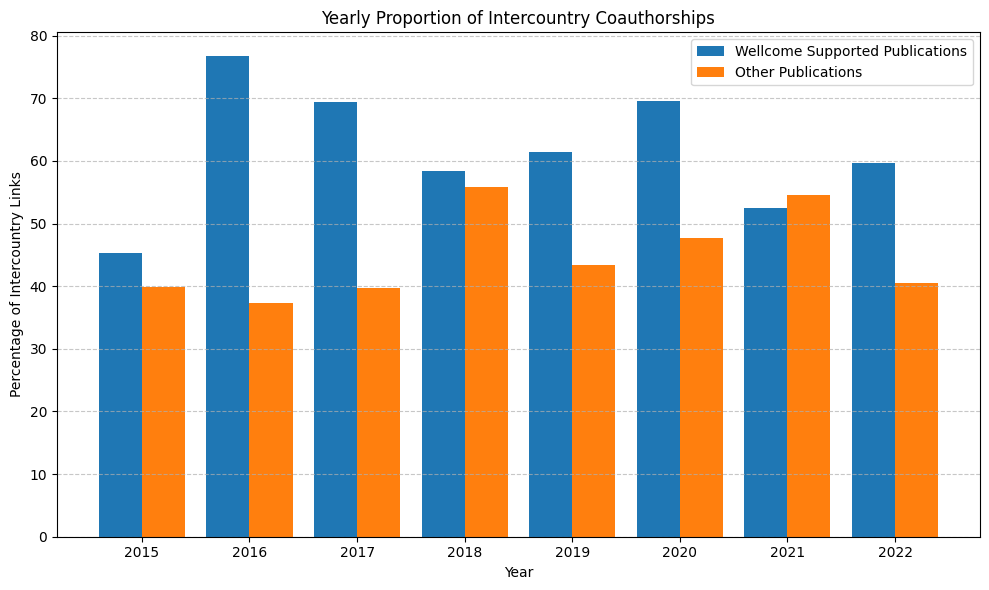

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Assume sorted_years, pct_wt_values, and pct_ch_values are defined

# Calculate the width of each bar
bar_width = 0.4

# Adjust positions for the bars
x_positions = np.arange(len(sorted_years))
x_positions_wt = x_positions - bar_width / 2  # Shift left for Wellcome Grants
x_positions_ch = x_positions + bar_width / 2  # Shift right for All C&H

# Create the bar chart
plt.figure(figsize=(10, 6))
plt.bar(x_positions_wt, pct_wt_values, width=bar_width, label='Wellcome Supported Publications')
plt.bar(x_positions_ch, pct_ch_values, width=bar_width, label='Other Publications')

# Customize the plot
plt.title('Yearly Proportion of Intercountry Coauthorships')
plt.xlabel('Year')
plt.ylabel('Percentage of Intercountry Links')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(x_positions, sorted_years)  # Set ticks at the center of grouped bars
plt.tight_layout()
plt.legend()

# Show the plot
plt.show()

### LMIC Proportion

In [18]:
countries_class = pd.read_excel('geographies/CH_files/CLASS.xlsx', sheet_name='List of economies')
lmic_list = countries_class[countries_class['Income group'].isin(['Low income', 'Lower middle income', 'Upper middle income'])]
lmic_list['Economy'] = lmic_list['Economy'].replace("Côte d’Ivoire", "Ivory Coast")
lmic_list['Economy'] = lmic_list['Economy'].replace("Gambia, The", "Gambia")
lmic_list['Economy'] = lmic_list['Economy'].replace("Iran, Islamic Rep.", "Iran")
lmic_list['Economy'] = lmic_list['Economy'].replace("Congo, Dem. Rep.", "Democratic Republic of the Congo")

/var/folders/dy/p3vg7l610wx7yc4y2908psy00000gp/T/ipykernel_28073/2822603552.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lmic_list['Economy'] = lmic_list['Economy'].replace("Côte d’Ivoire", "Ivory Coast")
/var/folders/dy/p3vg7l610wx7yc4y2908psy00000gp/T/ipykernel_28073/2822603552.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lmic_list['Economy'] = lmic_list['Economy'].replace("Gambia, The", "Gambia")
/var/folders/dy/p3vg7l610wx7yc4y2908psy00000gp/T/ipykernel_28073/2822603552.py:5: SettingWithCo

In [19]:
all_ch_lmic = {}

for year in  all_ch_loc.adjacency_matrices:
    total = 0
    for country in all_ch_loc.adjacency_matrices[year]['All'].index:
        if country == 'All' or country == 'total':
            continue
        for country2 in all_ch_loc.adjacency_matrices[year]['All'][country].index:
            if country2 == 'All' or country == 'total':
                continue
            if country in list(lmic_list['Economy']) or country2 in list(lmic_list['Economy']):
                total += all_ch_loc.adjacency_matrices[year]['All'][country][country2]
    all_ch_lmic[year] = (total, all_ch_loc.adjacency_matrices[year]['All']['All']['All'])

In [20]:
wt_ch_lmic = {}

for year in  wt_ch_loc.adjacency_matrices:
    total = 0
    for country in wt_ch_loc.adjacency_matrices[year]['All'].index:
        if country == 'All' or country == 'total':
            continue
        for country2 in wt_ch_loc.adjacency_matrices[year]['All'][country].index:
            if country2 == 'All' or country == 'total':
                continue
            elif country in list(lmic_list['Economy']) or country2 in list(lmic_list['Economy']):
                total += wt_ch_loc.adjacency_matrices[year]['All'][country][country2]
    wt_ch_lmic[year] = (total, wt_ch_loc.adjacency_matrices[year]['All']['All']['All'])

In [21]:
pct_lmic_ch = {}
pct_lmic_wt = {}

for year in all_ch_loc.adjacency_matrices:
    pct_lmic_ch[year] = all_ch_lmic[year][0]*100/all_ch_lmic[year][1]

pct_lmic_ch_values = [pct_lmic_ch[year] for year in sorted_years]

for year in wt_ch_loc.adjacency_matrices:
    pct_lmic_wt[year] = wt_ch_lmic[year][0]*100/wt_ch_lmic[year][1]

pct_lmic_wt_values = [pct_lmic_wt[year] for year in sorted_years]

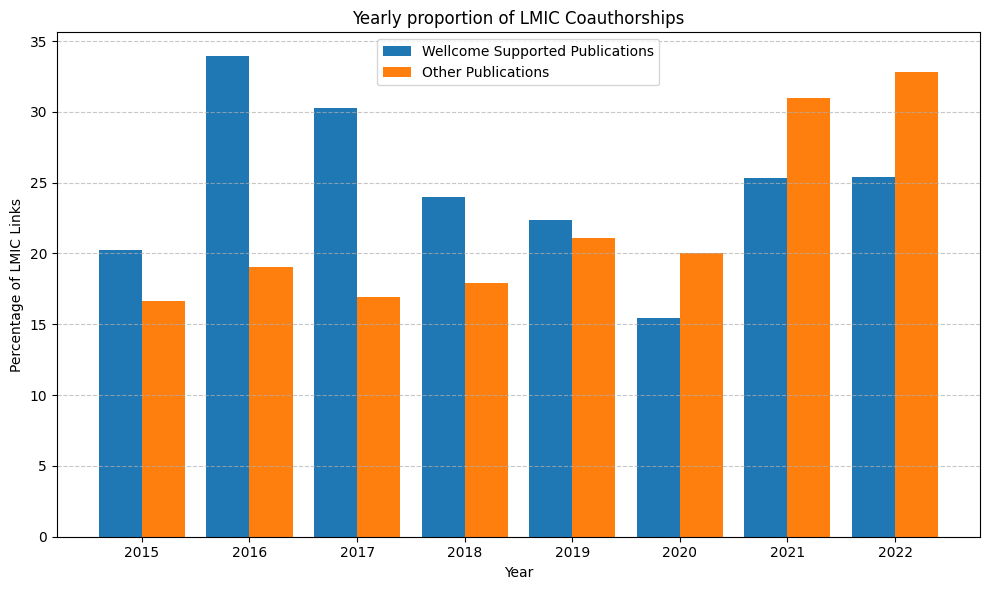

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Assume sorted_years, pct_lmic_wt_values, and pct_lmic_ch_values are defined

# Calculate the width of each bar
bar_width = 0.4

# Adjust positions for the bars
x_positions = np.arange(len(sorted_years))
x_positions_wt = x_positions - bar_width / 2  # Shift left for Wellcome Grants
x_positions_ch = x_positions + bar_width / 2  # Shift right for All C&H

# Create the bar chart
plt.figure(figsize=(10, 6))
plt.bar(x_positions_wt, pct_lmic_wt_values, width=bar_width, label='Wellcome Supported Publications')
plt.bar(x_positions_ch, pct_lmic_ch_values, width=bar_width, label='Other Publications')

# Customize the plot
plt.title('Yearly proportion of LMIC Coauthorships')
plt.xlabel('Year')
plt.ylabel('Percentage of LMIC Links')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(x_positions, sorted_years)  # Set ticks at the center of grouped bars
plt.tight_layout()
plt.legend()

# Show the plot
plt.show()


### Top interconnected LMIC countries

In [23]:
years = []
for year in wt_ch_loc.adjacency_matrices:
    years.append(year)

In [24]:
years.remove(2023)
years = [year for year in years if year >= 2012]

In [25]:
top_wt_countries = {}
for year in sorted(years):
    data = wt_ch_loc.adjacency_matrices[year]['All']['All']
    sorted_data = dict(sorted(data.items(), key=lambda item: item[1], reverse=True))
    filtered_data = {key: value for key, value in sorted_data.items() if key in list(lmic_list['Economy'])}
    top_wt_countries[year] =  dict(list(filtered_data.items())[:3])

top_wt_countries

{np.int64(2015): {'Kenya': 8.0},
 np.int64(2016): {'Sierra Leone': 511.0, 'Nigeria': 219.0, 'Guinea': 146.0},
 np.int64(2017): {'Sierra Leone': 588.0, 'Vietnam': 288.0, 'Nigeria': 252.0},
 np.int64(2018): {'Peru': 275.0, 'Madagascar': 118.0, 'Iran': 108.0},
 np.int64(2019): {'South Africa': 306.0, 'Peru': 288.0, 'Bangladesh': 154.0},
 np.int64(2020): {'Colombia': 683.0, 'South Africa': 421.0, 'Peru': 283.0},
 np.int64(2021): {'Peru': 693.0, 'Brazil': 502.0, 'South Africa': 457.0},
 np.int64(2022): {'Brazil': 435.0, 'Peru': 370.0, 'South Africa': 339.0}}

In [26]:
years = list(top_wt_countries.keys())

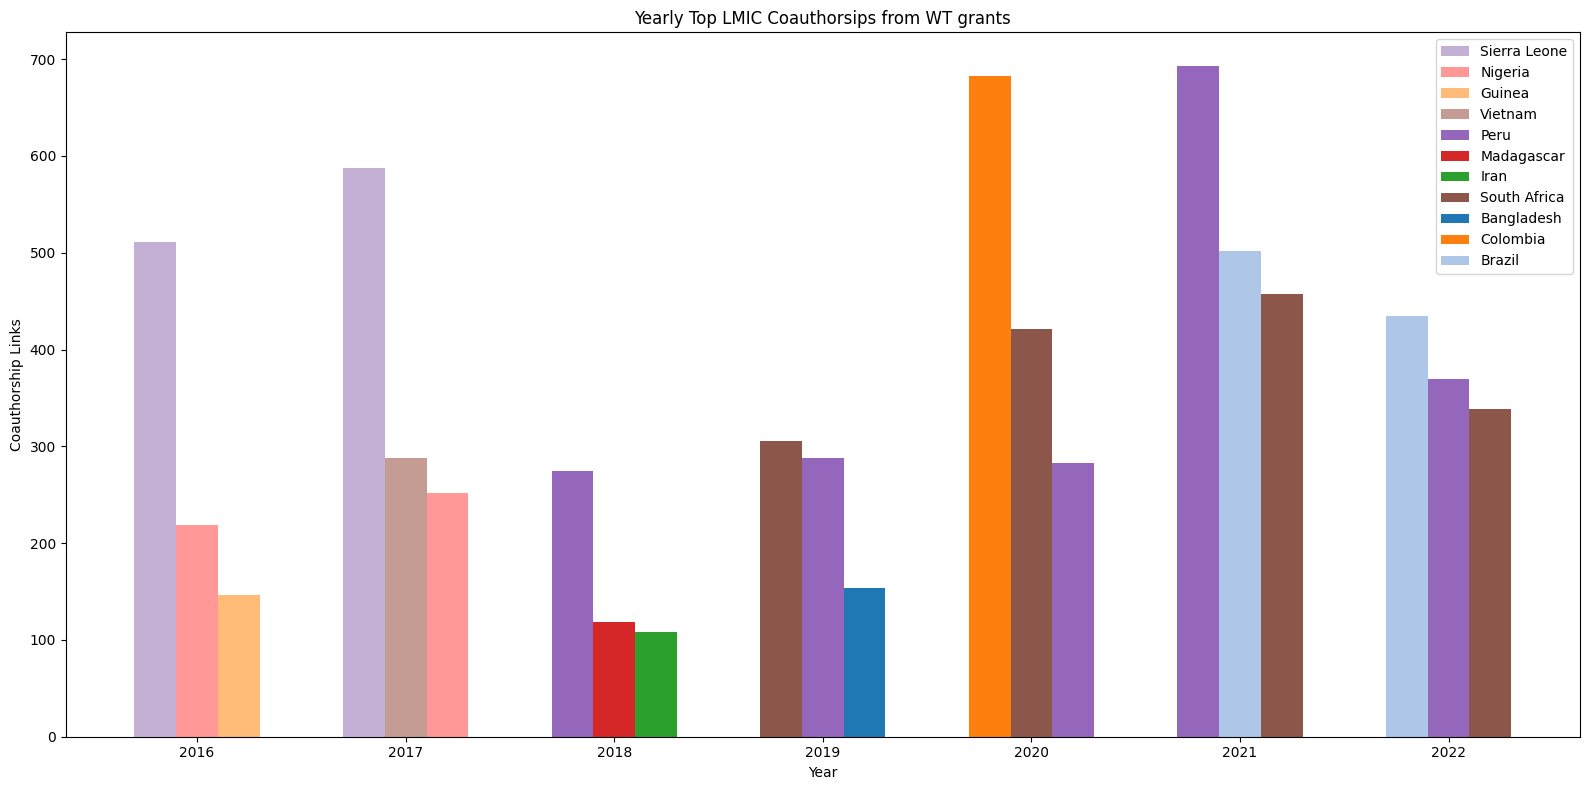

In [30]:
import numpy as np
import matplotlib.pyplot as plt


# Extract years and unique countries
years = list(top_wt_countries.keys())
years.remove(2015)
countries = sorted(set(country for year_data in top_wt_countries.values() for country in year_data))

# Define color map for each country
color_map = {country: plt.cm.tab20(i) for i, country in enumerate(countries)}

# Bar width and index setup
bar_width = 0.2
index = np.arange(len(years))

# Track which countries have been added to the legend
plotted_countries = set()

# Plot setup
fig, ax = plt.subplots(figsize=(16, 8))

# Plot each year's data, keeping colors consistent for each country
for j, year in enumerate(years):
    year_data = top_wt_countries[year]
    countries_in_year = list(year_data.keys())
    num_countries = len(countries_in_year)
    
    # Calculate offset to center the bars around each year
    offset = (num_countries - 1) / 2 * bar_width
    
    # Plot each country's data for this year
    for i, country in enumerate(countries_in_year):
        value = year_data[country]
        # Calculate the position for each bar
        position = index[j] - offset + i * bar_width
        # Add country to legend only once
        if country not in plotted_countries:
            ax.bar(position, value, bar_width, label=country, color=color_map[country])
            plotted_countries.add(country)
        else:
            ax.bar(position, value, bar_width, color=color_map[country])

# Labels and titles
ax.set_xlabel('Year')
ax.set_ylabel('Coauthorship Links')
ax.set_title('Yearly Top LMIC Coauthorsips from WT grants')
ax.set_xticks(index)
ax.set_xticklabels([str(year) for year in years])

# Display a single legend with all countries
ax.legend()

# Layout adjustment
plt.xticks()
plt.tight_layout()

# Show plot
plt.show()

In [31]:
years = []
for year in all_ch_loc.adjacency_matrices:
    years.append(year)

top_ch_countries = {}
for year in sorted(years):
    data = all_ch_loc.adjacency_matrices[year]['All']['All']
    sorted_data = dict(sorted(data.items(), key=lambda item: item[1], reverse=True))
    filtered_data = {key: value for key, value in sorted_data.items() if key in list(lmic_list['Economy'])}
    top_ch_countries[year] =  dict(list(filtered_data.items())[:3])

top_ch_countries

{np.int64(2014): {'Brazil': 4628.0, 'India': 1654.0, 'South Africa': 1610.0},
 np.int64(2015): {'Brazil': 7804.0, 'India': 1884.0, 'Mexico': 1315.0},
 np.int64(2016): {'Brazil': 21994.0, 'South Africa': 2279.0, 'India': 2267.0},
 np.int64(2017): {'Brazil': 8036.0, 'India': 3125.0, 'South Africa': 1988.0},
 np.int64(2018): {'Brazil': 18194.0, 'India': 4788.0, 'Mexico': 4261.0},
 np.int64(2019): {'Brazil': 30759.0, 'India': 4282.0, 'South Africa': 3067.0},
 np.int64(2020): {'Brazil': 21687.0, 'India': 7280.0, 'South Africa': 3770.0},
 np.int64(2021): {'Brazil': 56248.0, 'Peru': 10427.0, 'India': 10233.0},
 np.int64(2022): {'Brazil': 106966.0, 'India': 13858.0, 'Mexico': 7311.0},
 np.int64(2023): {'Brazil': 6177.0, 'India': 2394.0, 'Pakistan': 869.0}}

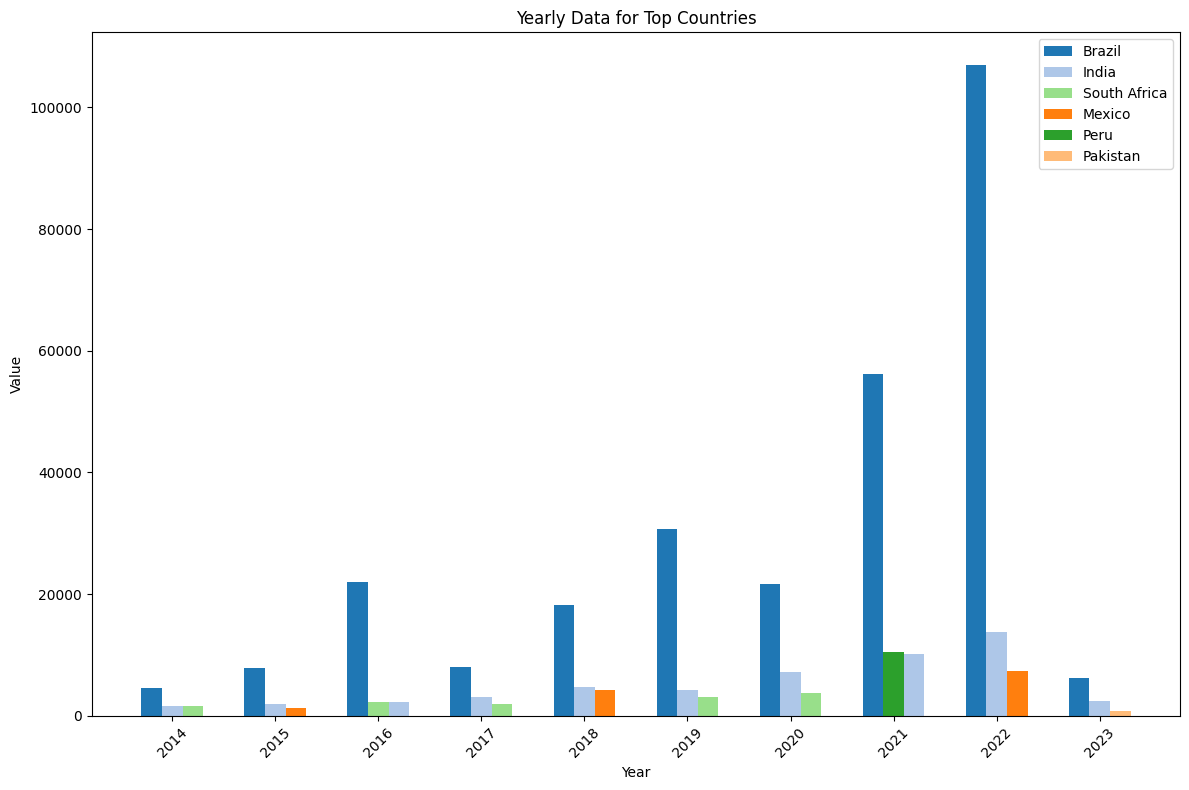

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Extract years and unique countries
years = list(top_ch_countries.keys())
countries = sorted(set(country for year_data in top_ch_countries.values() for country in year_data))

# Define color map for each country
color_map = {country: plt.cm.tab20(i) for i, country in enumerate(countries)}

# Bar width and index setup
bar_width = 0.2
index = np.arange(len(years))

# Track which countries have been added to the legend
plotted_countries = set()

# Plot setup
fig, ax = plt.subplots(figsize=(12, 8))

# Plot each year's data, keeping colors consistent for each country
for j, year in enumerate(years):
    year_data = top_ch_countries[year]
    countries_in_year = list(year_data.keys())
    num_countries = len(countries_in_year)
    
    # Calculate offset to center the bars around each year
    offset = (num_countries - 1) / 2 * bar_width
    
    # Plot each country's data for this year
    for i, country in enumerate(countries_in_year):
        value = year_data[country]
        # Calculate the position for each bar
        position = index[j] - offset + i * bar_width
        # Add country to legend only once
        if country not in plotted_countries:
            ax.bar(position, value, bar_width, label=country, color=color_map[country])
            plotted_countries.add(country)
        else:
            ax.bar(position, value, bar_width, color=color_map[country])

# Labels and titles
ax.set_xlabel('Year')
ax.set_ylabel('Value')
ax.set_title('Yearly Data for Top Countries')
ax.set_xticks(index)
ax.set_xticklabels([str(year) for year in years])

# Display a single legend with all countries
ax.legend()

# Layout adjustment
plt.xticks(rotation=45)
plt.tight_layout()

# Show plot
plt.show()
